# LSTM gesture model evaluation

이 노트북은 `artifacts/prepared_005`와 `runs/lstm/prepared_005_label_smoothing_005/best.pt`를 기준으로 개선된 4클래스 모델을 다시 평가합니다. `training/train.py`의 로더와 평가 함수를 직접 사용하므로 학습 코드와 평가 코드가 서로 달라지는 것을 방지합니다.

위에서부터 순서대로 실행하세요. 프로젝트 루트 또는 `training` 폴더에서 노트북을 열어도 동작합니다.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (cwd, cwd.parent)
     if (candidate / 'training' / 'train.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(
        '프로젝트 루트 또는 training 폴더에서 이 노트북을 실행하세요.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'artifacts' / 'prepared_005'
RUN_DIR = PROJECT_ROOT / 'runs' / 'lstm' / 'prepared_005_label_smoothing_005'
CHECKPOINT_PATH = RUN_DIR / 'best.pt'
HISTORY_PATH = RUN_DIR / 'history.json'
METRICS_PATH = RUN_DIR / 'test_metrics.json'

for required_path in (DATA_DIR, CHECKPOINT_PATH, HISTORY_PATH):
    if not required_path.exists():
        raise FileNotFoundError(f'필수 경로가 없습니다: {required_path}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Data:         {DATA_DIR}')
print(f'Checkpoint:   {CHECKPOINT_PATH}')

Project root: C:\Users\Admin\sunub_win\jesture_project
Data:         C:\Users\Admin\sunub_win\jesture_project\artifacts\prepared_005
Checkpoint:   C:\Users\Admin\sunub_win\jesture_project\runs\lstm\prepared_005_label_smoothing_005\best.pt


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn

from training.models import LSTMClassifier
from training.train import (
    build_loader,
    collect_predictions,
    evaluate,
    load_metadata,
    load_split,
)

## 1. 전처리 데이터 확인

저장된 `seq_len`, `feature_dim`, label map을 기준으로 train/validation/test 배열의 dtype과 shape, label 범위를 다시 검사합니다.

In [3]:
label_map, preprocessing_config = load_metadata(DATA_DIR)
class_names = tuple(
    name for name, _ in sorted(label_map.items(), key=lambda item: item[1])
)
seq_len = int(preprocessing_config['seq_len'])
feature_dim = int(preprocessing_config['feature_dim'])
num_classes = len(class_names)

splits = {}
for split_name in ('train', 'val', 'test'):
    splits[split_name] = load_split(
        DATA_DIR, split_name, seq_len, feature_dim, num_classes
    )

summary_rows = []
for split_name, (features, labels) in splits.items():
    counts = torch.bincount(labels, minlength=num_classes).tolist()
    row = {
        'split': split_name,
        'samples': len(labels),
        'X_shape': str(tuple(features.shape)),
        'X_dtype': str(features.dtype),
        'y_dtype': str(labels.dtype),
    }
    row.update({name: counts[index] for index, name in enumerate(class_names)})
    summary_rows.append(row)

print(f'Classes: {class_names}')
print(f'Sequence contract: ({seq_len}, {feature_dim})')
display(pd.DataFrame(summary_rows).set_index('split'))

Classes: ('swipe_left', 'make_fist', 'no_gesture', 'finger_snap')
Sequence contract: (32, 66)


,samples,X_shape,X_dtype,y_dtype,swipe_left,make_fist,no_gesture,finger_snap
split,,,,,,,,
train,792,"(792, 32, 66)",torch.float32,torch.int64,239,204,99,250
val,498,"(498, 32, 66)",torch.float32,torch.int64,87,103,100,208
test,288,"(288, 32, 66)",torch.float32,torch.int64,98,100,40,50


## 2. best checkpoint 복원 및 성능 재계산

체크포인트의 모델 설정과 전처리 설정이 일치하는지 확인한 뒤 현재 `evaluate()`로 test 성능을 다시 계산합니다. 저장된 `test_metrics.json`과 재계산값이 일치하는지도 함께 확인합니다.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(
    CHECKPOINT_PATH, map_location=device, weights_only=False
)

if checkpoint['label_map'] != label_map:
    raise ValueError('체크포인트와 prepared data의 label_map이 다릅니다.')
if checkpoint['model_config']['input_size'] != feature_dim:
    raise ValueError('모델 input_size와 prepared data feature_dim이 다릅니다.')
if checkpoint['model_config']['num_classes'] != num_classes:
    raise ValueError('모델 num_classes와 label 수가 다릅니다.')

model = LSTMClassifier(**checkpoint['model_config']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

saved_weights = checkpoint.get('class_weights')
class_weights = (
    torch.tensor(saved_weights, dtype=torch.float32, device=device)
    if saved_weights is not None else None
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

x_test, y_test = splits['test']
test_loader = build_loader(
    x_test, y_test, batch_size=64, shuffle=False, seed=42,
    pin_memory=device.type == 'cuda', workers=0,
)
recomputed_metrics = evaluate(
    model, test_loader, criterion, device, num_classes
)

stored_metrics = {}
if METRICS_PATH.is_file():
    stored_metrics = json.loads(
        METRICS_PATH.read_text(encoding='utf-8')
    ).get('test', {})

comparison = pd.DataFrame(
    [stored_metrics, recomputed_metrics],
    index=['stored result', 'recomputed (current code)'],
)[['loss', 'accuracy', 'macro_f1']]
print(f"Device: {device}; best epoch: {checkpoint['epoch']}")
display(comparison.style.format('{:.6f}'))

Device: cpu; best epoch: 19


,loss,accuracy,macro_f1
stored result,0.669937,0.909722,0.836088
recomputed (current code),0.669937,0.909722,0.836088


## 3. 학습 history 시각화

이 실험의 train loss에는 label smoothing 0.05가 적용되고 validation loss에는 원래 CrossEntropy가 사용됩니다. 두 곡선의 절대값보다 변화 추세와 일반화 간격을 중심으로 확인합니다.

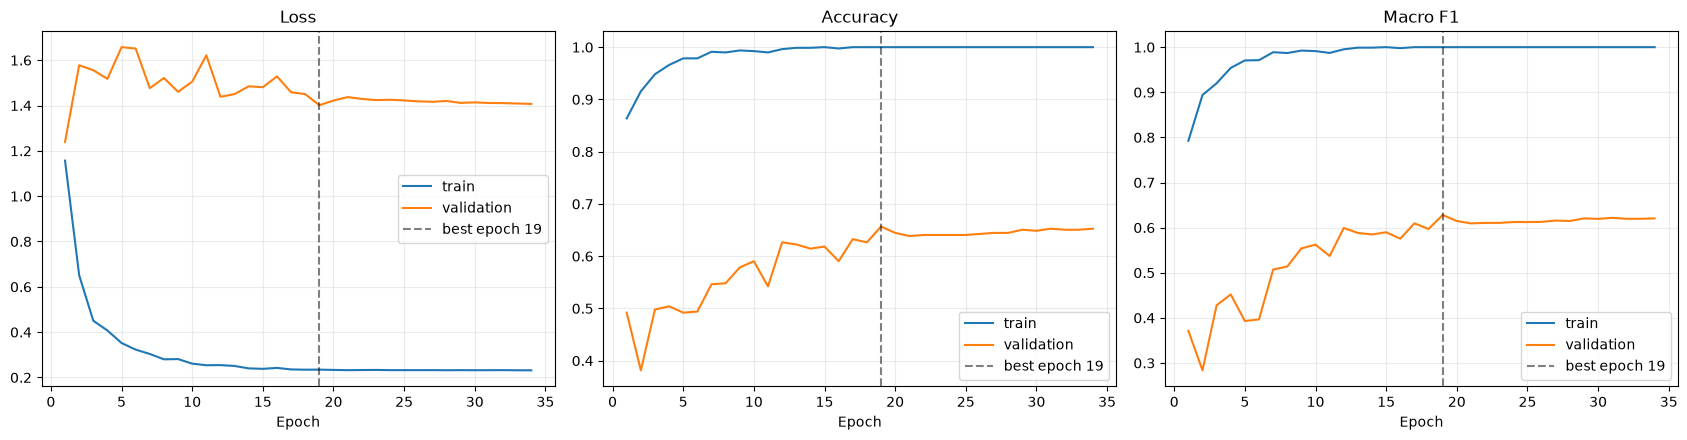

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
29,30,0.000063,0.231943,1.0,1.0,1.413734,0.648594,0.619414
30,31,0.000031,0.232144,1.0,1.0,1.411139,0.652610,0.621690
31,32,0.000031,0.232368,1.0,1.0,1.410521,0.650602,0.619588
32,33,0.000031,0.231769,1.0,1.0,1.408811,0.650602,0.619588
33,34,0.000031,0.231464,1.0,1.0,1.407030,0.652610,0.620432


In [5]:
history = json.loads(HISTORY_PATH.read_text(encoding='utf-8'))
history_df = pd.DataFrame(history)
best_epoch = int(checkpoint['epoch'])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
plots = [
    ('Loss', 'train_loss', 'val_loss'),
    ('Accuracy', 'train_accuracy', 'val_accuracy'),
    ('Macro F1', 'train_macro_f1', 'val_macro_f1'),
]
for axis, (title, train_column, val_column) in zip(axes, plots):
    axis.plot(history_df['epoch'], history_df[train_column], label='train')
    axis.plot(history_df['epoch'], history_df[val_column], label='validation')
    axis.axvline(best_epoch, color='black', linestyle='--', alpha=0.5,
                 label=f'best epoch {best_epoch}')
    axis.set(title=title, xlabel='Epoch')
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
plt.show()
display(history_df.tail())

## 4. confusion matrix와 per-class 성능

전체 정확도만으로 가려질 수 있는 클래스별 오분류를 확인합니다. 행은 실제 클래스, 열은 예측 클래스입니다.

In [ ]:
y_true, y_pred, probabilities = collect_predictions(
    model, test_loader, device
)

confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
np.add.at(confusion, (y_true, y_pred), 1)
row_totals = confusion.sum(axis=1, keepdims=True)
normalized_confusion = np.divide(
    confusion, row_totals,
    out=np.zeros_like(confusion, dtype=np.float64),
    where=row_totals != 0,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, matrix, title, fmt in (
    (axes[0], confusion, 'Confusion matrix (count)', 'd'),
    (axes[1], normalized_confusion, 'Confusion matrix (row ratio)', '.2f'),
):
    image = axis.imshow(matrix, cmap='Blues', vmin=0)
    axis.set(xticks=range(num_classes), yticks=range(num_classes),
             xticklabels=class_names, yticklabels=class_names,
             xlabel='Predicted', ylabel='True', title=title)
    plt.setp(axis.get_xticklabels(), rotation=30, ha='right')
    for row in range(num_classes):
        for column in range(num_classes):
            axis.text(column, row, format(matrix[row, column], fmt),
                      ha='center', va='center')
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
plt.show()

In [ ]:
per_class_rows = []
for class_id, class_name in enumerate(class_names):
    true_positive = int(np.sum((y_true == class_id) & (y_pred == class_id)))
    false_positive = int(np.sum((y_true != class_id) & (y_pred == class_id)))
    false_negative = int(np.sum((y_true == class_id) & (y_pred != class_id)))
    support = int(np.sum(y_true == class_id))
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall else 0.0
    )
    per_class_rows.append({
        'class': class_name, 'precision': precision, 'recall': recall,
        'f1': f1, 'support': support,
    })

per_class = pd.DataFrame(per_class_rows).set_index('class')
display(per_class.style.format({
    'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'
}))

## 5. confidence 분포와 misclassified samples

Softmax confidence는 실제 정확도가 아닙니다. 정답/오답 confidence 분포와 높은 확률로 틀린 샘플을 함께 확인해 실시간 임계값을 조정할 근거로 사용합니다.

In [ ]:
confidence = probabilities.max(axis=1)
correct = y_true == y_pred

plt.figure(figsize=(9, 4.5))
plt.hist(confidence[correct], bins=20, alpha=0.7, label='correct')
if np.any(~correct):
    plt.hist(confidence[~correct], bins=20, alpha=0.7, label='incorrect')
plt.axvline(0.65, color='black', linestyle='--', label='realtime threshold 0.65')
plt.xlabel('Maximum softmax confidence')
plt.ylabel('Samples')
plt.title('Prediction confidence distribution')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

misclassified_rows = []
for sample_index in np.flatnonzero(~correct):
    row = {
        'test_index': int(sample_index),
        'true': class_names[int(y_true[sample_index])],
        'predicted': class_names[int(y_pred[sample_index])],
        'confidence': float(confidence[sample_index]),
    }
    row.update({
        f'p_{name}': float(probabilities[sample_index, class_id])
        for class_id, name in enumerate(class_names)
    })
    misclassified_rows.append(row)

misclassified = pd.DataFrame(misclassified_rows)
if misclassified.empty:
    print('Misclassified samples: 0')
else:
    misclassified = misclassified.sort_values('confidence', ascending=False)
    print(f'Misclassified samples: {len(misclassified)} / {len(y_true)}')
    display(misclassified.head(20).style.format({
        column: '{:.3f}'
        for column in misclassified.columns
        if column == 'confidence' or column.startswith('p_')
    }))

## 해석 시 주의사항

- `stored result`와 현재 재계산 결과가 다르면 데이터 폴더, 체크포인트 또는 평가 코드가 변경됐는지 확인해야 합니다.
- 실시간 프로그램의 클래스별 퍼센트는 softmax confidence이지 측정된 정확도가 아닙니다.
- validation과 test 성능 차이가 크다면 한 번의 participant split만으로 일반화를 판단하지 말고 participant 기반 교차검증을 추가해야 합니다.
- 다른 학습 실행을 분석하려면 첫 코드 셀의 `DATA_DIR`와 `RUN_DIR`만 함께 변경하세요.